In [6]:
from scipy.optimize import minimize # finding optimal params in models
from scipy import stats             # statistical tools
import numpy as np                  # matrix/array functions
import pandas as pd                 # loading and manipulating data
import ipywidgets as widgets        # interactive display
import matplotlib.pyplot as plt     # plotting
import os
%matplotlib inline
import learning_models as lm

subject_id = 1
np.random.seed(2021)                # set seed for reproducibility

In [7]:
# Make output folder
output_dir = os.path.join('..','plots','learning_models')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [8]:
# Load probability sequence
sequence_path = os.path.join('..','..','phd_1_task','resources',f'parameters_per_stimuli_sub-{subject_id:003}_session-01.csv')
original_dataframe = pd.read_csv(sequence_path)
original_dataframe['probability_sequence'] = original_dataframe['probability_sequence'].div(100).round(2)
stimuli_types = [1,2,3,4]

## Reorganise into a dataframe containing only the probability sequences
probability_dataframe = pd.DataFrame()
for i, stimuli_type in enumerate(stimuli_types):
    filtered_dataframe = (original_dataframe.loc[original_dataframe['stimuli_type'] == stimuli_type]).reset_index()
    probability_dataframe[f'stimuli_type_{stimuli_type}'] = filtered_dataframe['probability_sequence']
print(probability_dataframe)

     stimuli_type_1  stimuli_type_2  stimuli_type_3  stimuli_type_4
0               0.5             0.5             0.5             0.5
1               0.5             0.5             0.5             0.5
2               0.5             0.5             0.5             0.2
3               0.5             0.5             0.5             0.2
4               0.2             0.8             0.2             0.2
..              ...             ...             ...             ...
115             0.2             0.8             0.8             0.8
116             0.2             0.8             0.8             0.8
117             0.2             0.8             0.8             0.8
118             0.2             0.8             0.8             0.8
119             0.2             0.8             0.8             0.8

[120 rows x 4 columns]


In [9]:
# Set variables needed for all models
trials = 120
K = 2
mu = [0.2, 0.8]

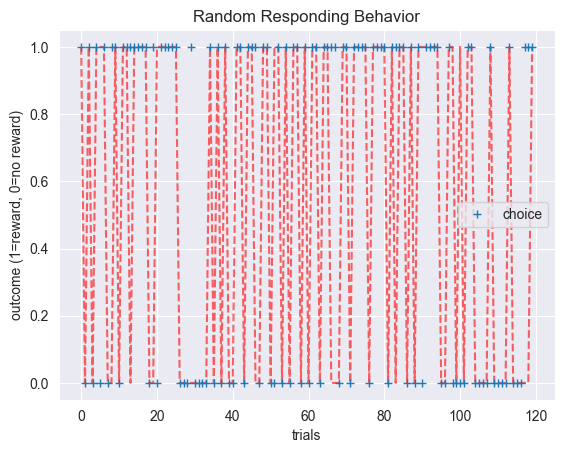

In [10]:
# simulate the random responding model and plot the results
choices_1, responses_1 = lm.simulate_random_responders(bias=.5, trials=trials, mu=mu)

## Plot the simulation
plt.plot(range(trials), responses_1, 'r--', alpha=.6)
plt.plot(range(trials), choices_1, '+', label='choice')
plt.xlabel('trials')
plt.ylabel('outcome (1=reward, 0=no reward)')
plt.title(f'Random Responding Behavior')
plt.legend()
plt.show()

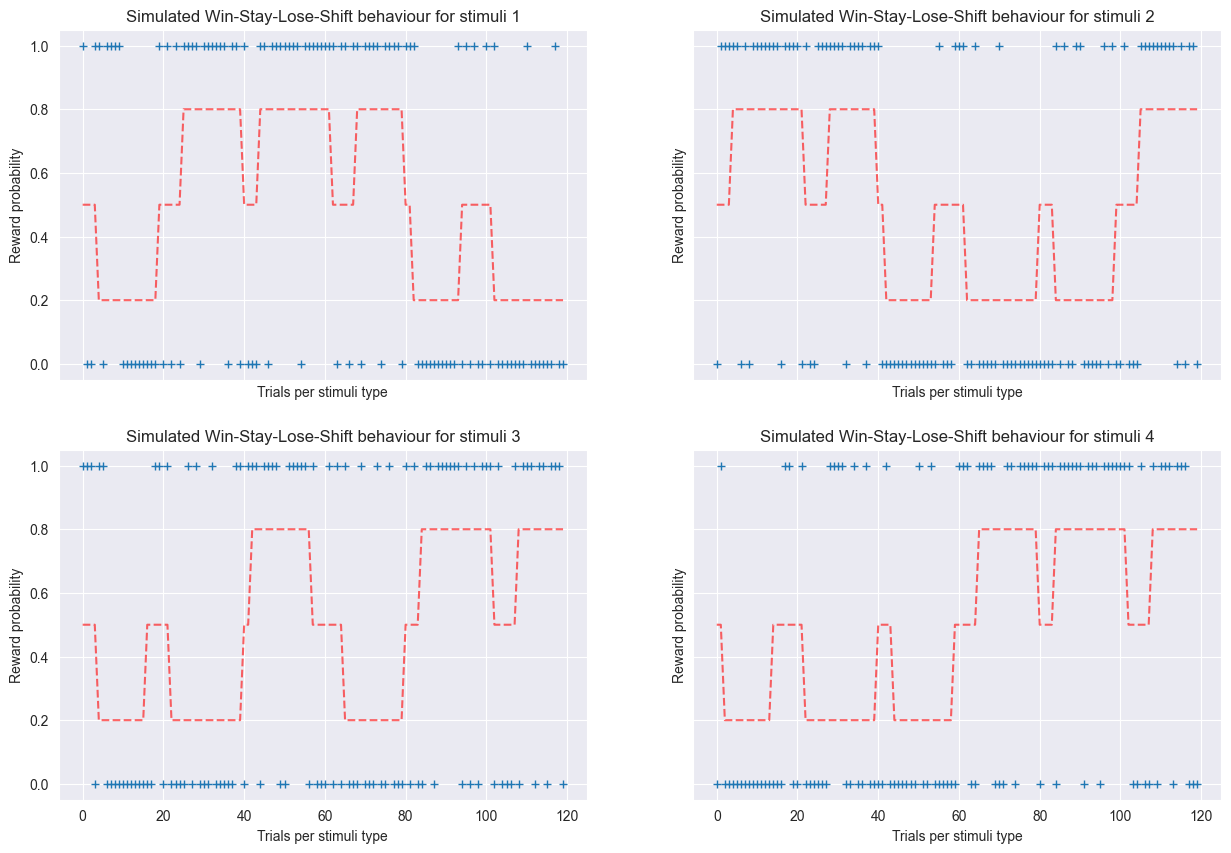

In [11]:
# Create plot with subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

# Loop through all stimuli_types to create subplots
for i, stimuli_type in enumerate(stimuli_types):
    
    # Turn pandas column to list
    mu_sequence = probability_dataframe[f'stimuli_type_{stimuli_type}'].tolist()
    
    # Run the WSLS simulation
    choices_2, responses_2 = lm.simulate_win_stay_lose_shift(epsilon=.1, trials=trials, mu_sequence=mu_sequence)
    
    ## Plot the WSLS simulation
    axs[i].plot(range(trials), mu_sequence, 'r--', alpha=.6)
    axs[i].plot(range(trials), choices_2, '+', label='choice')
    axs[i].set_xlabel('Trials per stimuli type')
    axs[i].set_ylabel('Reward probability')
    axs[i].set_title(f'Simulated Win-Stay-Lose-Shift behaviour for stimuli {stimuli_type}')

plt.savefig(os.path.join(output_dir, f'simulated_wsls_behaviour_sub-{subject_id:-003}.pdf'))
plt.show()

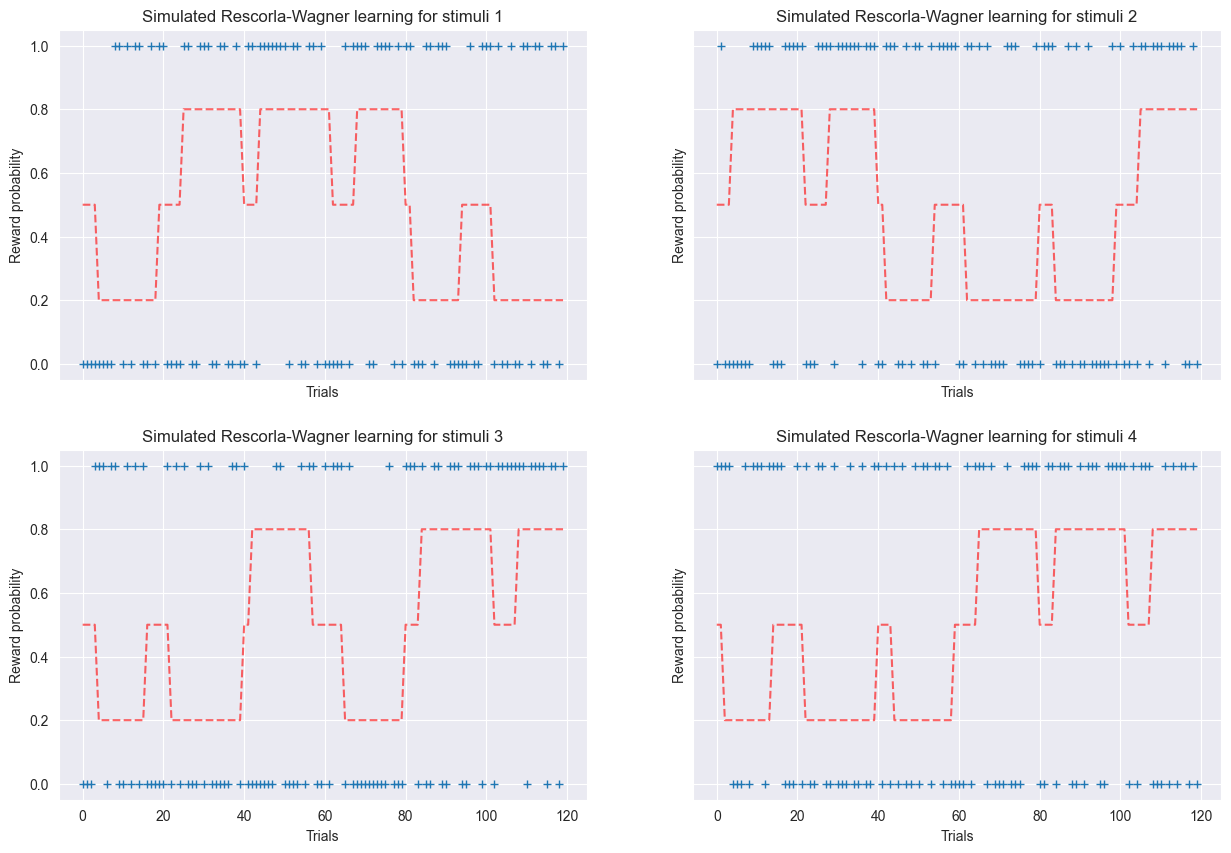

<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [18]:
# Create plot with subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

# Loop through all stimuli_types to create subplots
for i, stimuli_type in enumerate(stimuli_types):

    # Turn pandas column to list
    mu_sequence = probability_dataframe[f'stimuli_type_{stimuli_type}'].tolist()
    
    # Run model
    choices_3, responses_3, Q = lm.simulate_rescorla_wagner(alpha=.1, theta=1.5, trials=trials, mu_sequence=mu_sequence)

    # plot the simulation
    axs[i].plot(range(trials), mu_sequence, 'r--', alpha=.6)
    axs[i].plot(range(trials), choices_3, '+', label='choice')
    axs[i].set_xlabel('Trials')
    axs[i].set_ylabel('Reward probability')
    axs[i].set_title(f'Simulated Rescorla-Wagner learning for stimuli {stimuli_type}')

plt.savefig(os.path.join(output_dir, f'simulated_rescorla_wagner_learning_sub-{subject_id:-003}.pdf'))
plt.show()
print(type(choices_3), type(responses_3), type(Q))

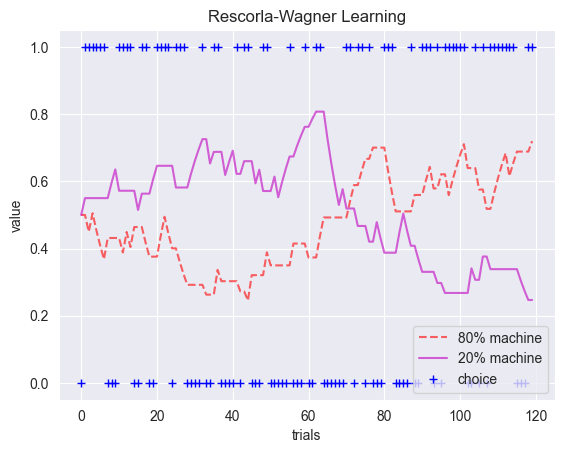

In [13]:
# plot the simulation
plt.plot(range(trials), Q[1,:], 'r--', alpha=.6, label='80% machine')
plt.plot(range(trials), Q[0,:], 'm-', alpha=.6, label='20% machine')
plt.plot(range(trials), choices_3, 'b+', label='choice')
plt.xlabel('trials')
plt.ylabel('value')
plt.title(f'Rescorla-Wagner Learning')
plt.legend()
plt.show()